# Verification: combinatorial histone H4 acetylation (Blasi et al., 2016)

Blasi et al. (2016) ask how the 16 combinatorial acetylation motifs of the
histone H4 tail — every subset of the lysines K5, K8, K12 and K16 — acquire the
very uneven abundances measured by LC-MS in *Drosophila melanogaster* KC cells.
They compare three hypotheses, each a mass-action network on the 4-cube whose
32 acetylation edges carry rate constants that are

* **unspecific** — one rate for every edge (Fig. 2A),
* **site-specific** — one rate per lysine, independent of context (Fig. 2B), or
* **motif-specific** — a basal rate plus seven context-dependent rates (Fig. 2C).

This is a rule-based question in disguise: the three scenarios differ only in
how much modification context a rule is allowed to name. The three curated BNGL
files encode exactly that difference, and this notebook verifies them at three
levels.

1. **Reproducibility** — rerun each `.bngl` file with BioNetGen 2.9.3 and
   compare against the committed `reference/` output.
2. **Model specification** — check that the generated network *is* the paper's
   network (16 motifs, 32 acetylation edges, 32 deacetylation edges, every edge
   at the rate constant listed in Table S2), then compare BioNetGen against an
   independent SciPy integration of the 16 linear ODEs.
3. **Reported data** — compare against the quantities the paper reports: the
   LC-MS motif abundances plotted in Fig. 2, the reference steady state of the
   PEtab benchmark implementation, and the three published BIC values.

Nothing here is digitized from a plotted figure: every reported quantity used
below exists as tabular data, extracted into `reference/` by
`extract_blasi2016.py`.

**Plot convention:** solid lines are BioNetGen; open markers are the
independent SciPy solution.

In [1]:
from pathlib import Path
import itertools
import os
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

MODEL_STEM = "combinatorial_histone_h4_acetylation_blasi2016"
VARIANTS = {
    "motif_specific": MODEL_STEM,
    "site_specific": f"{MODEL_STEM}_site_specific",
    "unspecific": f"{MODEL_STEM}_unspecific",
}


def find_model_dir():
    candidates = [Path.cwd(), Path.cwd() / "models" / MODEL_STEM]
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidates.append(parent / "models" / MODEL_STEM)
    for candidate in candidates:
        if (candidate / f"{MODEL_STEM}.bngl").exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Cannot locate {MODEL_STEM}.bngl")


def find_bng2():
    if os.environ.get("BNG2_PL"):
        return Path(os.environ["BNG2_PL"]).resolve()
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.exists():
        return local
    found = shutil.which("BNG2.pl")
    if found:
        return Path(found).resolve()
    raise FileNotFoundError("BioNetGen not found; set BNG2_PL")


def load_gdat(path):
    header = Path(path).read_text().splitlines()[0].lstrip("#").split()
    return pd.DataFrame(np.loadtxt(path, comments="#"), columns=header)


MODEL_DIR = find_model_dir()
REFERENCE = MODEL_DIR / "reference"
BNG2 = find_bng2()
print(f"Model directory: {MODEL_DIR}")
print(f"BioNetGen: {BNG2}")

Model directory: /Users/l119605/Code/BNGL-Models/models/combinatorial_histone_h4_acetylation_blasi2016
BioNetGen: /Users/l119605/Simulations/BioNetGen-2.9.3/BNG2.pl


## Motif bookkeeping

The 16 motifs are the vertices of a 4-cube and the 32 acetylation reactions are
its edges. Everything below indexes motifs by the same labels the paper uses in
Figs. 1B and 2, so BioNetGen observables, the independent solution and the
measurement table can be lined up column by column.

In [2]:
SITES = ("k5", "k8", "k12", "k16")


def motif_name(state):
    marked = [site for site, bit in zip(SITES, state) if bit]
    if not marked:
        return "0ac"
    if len(marked) == 4:
        return "4ac"
    return "".join(marked)


STATES = list(itertools.product((0, 1), repeat=4))
MOTIFS = [motif_name(state) for state in STATES]
MOTIF_INDEX = {motif: i for i, motif in enumerate(MOTIFS)}

# Layer = number of acetyl marks. Motifs are displayed layer by layer and, within
# a layer, in lysine order, which is the arrangement of Figs. 1B and 2.
LAYER = {motif: sum(state) for motif, state in zip(MOTIFS, STATES)}
ORDER = sorted(
    MOTIFS,
    key=lambda m: (LAYER[m], [i for i, s in enumerate(STATES[MOTIF_INDEX[m]]) if s]),
)


def observable_name(motif):
    if motif in ("0ac", "4ac"):
        return f"Obs_{motif}"
    return "Obs_" + motif.replace("k", "K")


ACETYLATION_EDGES = []
for state in STATES:
    for position, site in enumerate(SITES):
        if state[position] == 0:
            product = list(state)
            product[position] = 1
            ACETYLATION_EDGES.append((motif_name(state), motif_name(tuple(product)), site))

print(f"{len(MOTIFS)} motifs, {len(ACETYLATION_EDGES)} acetylation edges")
print("display order:", " ".join(ORDER))

16 motifs, 32 acetylation edges
display order: 0ac k5 k8 k12 k16 k5k8 k5k12 k5k16 k8k12 k8k16 k12k16 k5k8k12 k5k8k16 k5k12k16 k8k12k16 4ac


## Fresh BioNetGen runs

Each `.bngl` file is copied to a scratch directory and run exactly as
distributed. The committed `reference/*_ode.gdat` files must be recovered to
round-off.

In [3]:
fresh = {}
generated_net = {}

with tempfile.TemporaryDirectory(prefix="blasi2016_") as temp_name:
    temp_dir = Path(temp_name)
    for scenario, stem in VARIANTS.items():
        shutil.copy2(MODEL_DIR / f"{stem}.bngl", temp_dir / f"{stem}.bngl")
        subprocess.run(
            ["perl", str(BNG2), f"{stem}.bngl"],
            cwd=temp_dir,
            check=True,
            capture_output=True,
            text=True,
        )
        fresh[scenario] = load_gdat(temp_dir / f"{stem}_ode.gdat")
        generated_net[scenario] = (temp_dir / f"{stem}.net").read_text()

for scenario, stem in VARIANTS.items():
    committed = load_gdat(REFERENCE / f"{stem}_ode.gdat")
    error = np.max(np.abs(fresh[scenario].to_numpy() - committed.to_numpy()))
    species_block = generated_net[scenario].split("begin species", 1)[1].split("end species", 1)[0]
    reaction_block = (
        generated_net[scenario].split("begin reactions", 1)[1].split("end reactions", 1)[0]
    )
    n_species = sum(bool(line.strip()) for line in species_block.splitlines())
    n_reactions = sum(bool(line.strip()) for line in reaction_block.splitlines())
    print(
        f"{scenario:>15}: {n_species:2d} species, {n_reactions:2d} reactions, "
        f"fresh vs committed max abs error {error:.2e}"
    )

 motif_specific: 16 species, 64 reactions, fresh vs committed max abs error 0.00e+00
  site_specific: 16 species, 64 reactions, fresh vs committed max abs error 0.00e+00
     unspecific: 16 species, 64 reactions, fresh vs committed max abs error 0.00e+00


## Is the generated network the paper's network?

The BNGL files never write a reaction down; they write rules over lysine
context, and BioNetGen expands them. That expansion is the thing to check. For
each scenario the generated `.net` is parsed, every species is mapped back to a
motif label, and the resulting edge list is compared with the 4-cube — including
the rate constant on every edge.

For the motif-specific model the expected rate constants are read from
`reference/blasi2016_tableS2_rank1_edge_rates.csv`, i.e. from the rank-1 row of
Table S2 in Blasi et al. (2016). This is the strictest form of the
model-specification check: 32 independent published numbers, one per edge, none
of them written explicitly in the BNGL file.

In [4]:
import re

table_s2 = pd.read_csv(REFERENCE / "blasi2016_tableS2_rank1_edge_rates.csv")
expected_rates = {
    "motif_specific": {
        (row.substrate_motif, row.product_motif): row.rate_constant
        for row in table_s2.itertuples()
    },
    "unspecific": {(a, b): 0.182 for a, b, _ in ACETYLATION_EDGES},
    "site_specific": {
        (a, b): {"k5": 0.225, "k8": 0.126, "k12": 0.417, "k16": 0.107}[site]
        for a, b, site in ACETYLATION_EDGES
    },
}


def parse_net(text):
    def block(name):
        body = text.split(f"begin {name}", 1)[1].split(f"end {name}", 1)[0]
        return [line for line in body.strip().splitlines() if line.strip()]

    motif_of = {}
    for line in block("species"):
        index, pattern = line.split()[:2]
        state = dict(re.findall(r"(k\d+)~(\w+)", pattern))
        motif_of[int(index)] = motif_name(tuple(state[site] == "ac" for site in SITES))

    parameters = {}
    for line in block("parameters"):
        fields = line.split()
        parameters[fields[1]] = float(fields[2])

    edges = {}
    for line in block("reactions"):
        fields = line.split()
        rate = fields[3]
        edges[(motif_of[int(fields[1])], motif_of[int(fields[2])])] = parameters.get(
            rate, None
        ) if rate in parameters else float(rate)
    return motif_of, edges


structural = []
for scenario in VARIANTS:
    motif_of, edges = parse_net(generated_net[scenario])
    forward = {(a, b) for a, b, _ in ACETYLATION_EDGES}
    backward = {(b, a) for a, b in forward}

    problems = []
    if sorted(motif_of.values()) != sorted(MOTIFS):
        problems.append("species do not enumerate the 16 motifs")
    if set(edges) != forward | backward:
        problems.append("edge set differs from the 4-cube")
    worst_rate = 0.0
    for edge in forward:
        want = expected_rates[scenario][edge]
        worst_rate = max(worst_rate, abs(edges[edge] - want) / want)
    deacetylation = {edges[edge] for edge in backward}
    if deacetylation != {1.0}:
        problems.append(f"deacetylation rates not all 1: {sorted(deacetylation)}")

    structural.append(
        {
            "scenario": scenario,
            "species": len(motif_of),
            "acetylation edges": len(forward),
            "deacetylation edges": len(backward),
            "max rate deviation": worst_rate,
            "problems": "; ".join(problems) or "none",
        }
    )

structural = pd.DataFrame(structural).set_index("scenario")
structural

,species,acetylation edges,deacetylation edges,max rate deviation,problems
scenario,,,,,
motif_specific,16,32,32,0.0,none
site_specific,16,32,32,0.0,none
unspecific,16,32,32,0.0,none


## Independent solution

The independent implementation does not read BioNetGen's `.net` file. It builds
the 16 x 16 generator of the linear network directly from the 4-cube edge list
and the published rate constants, integrates it with SciPy from unmodified H4,
and — separately — solves for the stationary distribution as a linear-algebra
problem with the conservation constraint sum(x) = 1. Agreement of the SciPy
endpoint with that null-space solution confirms that `t_end = 50` really has
reached steady state.

In [5]:
DEACETYLATION = 1.0

reported = pd.read_csv(REFERENCE / "blasi2016_reported_rate_constants.csv")
REPORTED = {
    scenario: dict(zip(group.parameter, group.estimate))
    for scenario, group in reported.groupby("scenario")
}


def edge_rates(scenario):
    """Acetylation rate constant on each edge, from the published estimates."""
    if scenario == "unspecific":
        return {(a, b): REPORTED["unspecific"]["a_b"] for a, b, _ in ACETYLATION_EDGES}
    if scenario == "site_specific":
        per_site = {
            "k5": REPORTED["site_specific"]["a_K5"],
            "k8": REPORTED["site_specific"]["a_K8"],
            "k12": REPORTED["site_specific"]["a_K12"],
            "k16": REPORTED["site_specific"]["a_K16"],
        }
        return {(a, b): per_site[site] for a, b, site in ACETYLATION_EDGES}
    # Motif-specific: the four-digit Table S2 values carried by the BNGL file.
    return {
        (row.substrate_motif, row.product_motif): row.rate_constant
        for row in table_s2.itertuples()
    }


def generator(scenario):
    A = np.zeros((16, 16))
    for (substrate, product), rate in edge_rates(scenario).items():
        i, j = MOTIF_INDEX[substrate], MOTIF_INDEX[product]
        A[j, i] += rate           # acetylation
        A[i, i] -= rate
        A[i, j] += DEACETYLATION  # deacetylation
        A[j, j] -= DEACETYLATION
    return A


def integrate(scenario, times):
    A = generator(scenario)
    x0 = np.zeros(16)
    x0[MOTIF_INDEX["0ac"]] = 1.0
    solution = solve_ivp(
        lambda _t, x: A @ x, (0.0, times[-1]), x0, t_eval=times,
        method="LSODA", rtol=1e-12, atol=1e-14,
    )
    return solution.y


def stationary(scenario):
    A = generator(scenario)
    M = np.vstack([A, np.ones(16)])
    b = np.zeros(17)
    b[-1] = 1.0
    return np.linalg.lstsq(M, b, rcond=None)[0]


independent = {}
rows = []
for scenario in VARIANTS:
    times = fresh[scenario]["time"].to_numpy()
    trajectory = integrate(scenario, times)
    independent[scenario] = trajectory

    bng = np.column_stack([fresh[scenario][observable_name(m)] for m in MOTIFS]).T
    scale = np.max(np.abs(bng), axis=1, keepdims=True)
    max_rel = np.max(np.abs(bng - trajectory) / scale)
    l2 = np.linalg.norm(bng - trajectory) / np.linalg.norm(bng)

    endpoint = trajectory[:, -1]
    rows.append(
        {
            "scenario": scenario,
            "max rel error (trajectory)": max_rel,
            "relative L2 error": l2,
            "SciPy endpoint vs null space": np.max(
                np.abs(endpoint - stationary(scenario)) / stationary(scenario)
            ),
            "sum of abundances": endpoint.sum(),
        }
    )

pd.DataFrame(rows).set_index("scenario")

,max rel error (trajectory),relative L2 error,SciPy endpoint vs null space,sum of abundances
scenario,,,,
motif_specific,2.476497e-09,6.584849e-11,5.755744e-14,1.0
site_specific,1.787291e-09,1.118495e-10,2.598392e-14,1.0
unspecific,1.883945e-09,1.124320e-10,2.488195e-14,1.0


## Steady state versus the reported data

Three comparisons, in increasing order of what they test.

**(a) The PEtab benchmark reference.** The `Blasi_CellSystems2016` problem of
the Benchmarking-Initiative collection ships a reference steady-state
simulation of the best motif-specific model. It is an entirely independent
implementation (SBML plus a stationary solve) of the same published model, so
agreement to solver tolerance is a check on the BNGL encoding.

**(b) The measured motif abundances.** The 252 LC-MS measurements plotted as x
markers in Fig. 2 — 18 biological replicates for most motifs, 12 for K5K12,
K8K12 and K8K16, and none for K5K16, which sits below the quantification limit.

**(c) The published BIC values.** Blasi et al. report BIC = 697.3, 644.5 and
67.1 for the three scenarios and rest their whole conclusion on those numbers.
Recomputing them from the log-error likelihood of Supplemental Experimental
Procedures section 2, using the steady states produced here, tests the model,
the rate constants and the data all at once.

In [6]:
petab_reference = pd.read_csv(REFERENCE / "blasi2016_petab_reference_abundances.csv")
petab_reference = dict(zip(petab_reference.motif, petab_reference.relative_abundance))

bng_steady = {
    scenario: {m: fresh[scenario][observable_name(m)].iloc[-1] for m in MOTIFS}
    for scenario in VARIANTS
}

deviation = max(
    abs(bng_steady["motif_specific"][m] - petab_reference[m]) / petab_reference[m]
    for m in MOTIFS
)
print(f"(a) BioNetGen vs PEtab benchmark reference, max relative error: {deviation:.2e}")

(a) BioNetGen vs PEtab benchmark reference, max relative error: 2.06e-08


In [7]:
measurements = pd.read_csv(REFERENCE / "feller2015_h4_motif_abundances.csv")
measured_mean = measurements.groupby("motif").relative_abundance.mean()
measured_n = measurements.groupby("motif").relative_abundance.count()

comparison = pd.DataFrame(
    {
        "layer": [LAYER[m] for m in ORDER],
        "measured mean": [measured_mean.get(m, np.nan) for m in ORDER],
        "replicates": [measured_n.get(m, 0) for m in ORDER],
        "unspecific": [bng_steady["unspecific"][m] for m in ORDER],
        "site-specific": [bng_steady["site_specific"][m] for m in ORDER],
        "motif-specific": [bng_steady["motif_specific"][m] for m in ORDER],
    },
    index=ORDER,
)
for column in ("unspecific", "site-specific", "motif-specific"):
    comparison[f"|log10| {column}"] = np.abs(
        np.log10(comparison[column] / comparison["measured mean"])
    )
comparison.round(6)

,layer,measured mean,replicates,unspecific,site-specific,motif-specific,|log10| unspecific,|log10| site-specific,|log10| motif-specific
0ac,0,0.732532,18,0.512307,0.462177,0.737632,0.155296,0.200018,0.003013
k5,1,0.034676,18,0.093240,0.103990,0.033423,0.429577,0.476966,0.015984
k8,1,0.031823,18,0.093240,0.058234,0.031482,0.466855,0.262432,0.004686
k12,1,0.073864,18,0.093240,0.192728,0.067128,0.101171,0.416513,0.041526
k16,1,0.033781,18,0.093240,0.049453,0.035926,0.440931,0.165522,0.026740
k5k8,2,0.006051,18,0.016970,0.013103,0.005669,0.447876,0.335564,0.028328
k5k12,2,0.048039,12,0.016970,0.043364,0.047962,0.451925,0.044471,0.000697
k5k16,2,NaN,0,0.016970,0.011127,0.003901,NaN,NaN,NaN
k8k12,2,0.008036,12,0.016970,0.024284,0.007670,0.324625,0.480267,0.020231
k8k16,2,0.004708,12,0.016970,0.006231,0.004315,0.556846,0.121735,0.037886


In [8]:
summary = {}
for column in ("unspecific", "site-specific", "motif-specific"):
    residual = comparison[f"|log10| {column}"].dropna()
    summary[column] = {
        "median |log10| deviation": residual.median(),
        "max |log10| deviation": residual.max(),
        "worst motif": residual.idxmax(),
        "max fold error": 10 ** residual.max(),
    }
print("(b) predicted steady state against the measured motif means")
display(pd.DataFrame(summary).T)

(b) predicted steady state against the measured motif means


,median |log10| deviation,max |log10| deviation,worst motif,max fold error
unspecific,0.371417,0.783536,4ac,6.074856
site-specific,0.250042,0.766471,4ac,5.840778
motif-specific,0.016892,0.045722,k5k12k16,1.11102


In [9]:
LONG = measurements.dropna(subset=["relative_abundance"])


def log_likelihood(prediction):
    """Log-error likelihood of Supplemental Experimental Procedures section 2.

    The empirical variance sigma^2 is the profiled maximum-likelihood value, so
    it is not counted as a free parameter -- consistent with the parameter
    counts the paper uses for the BIC.
    """
    residual = np.array(
        [
            np.log(row.relative_abundance) - np.log(prediction[row.motif])
            for row in LONG.itertuples()
        ]
    )
    n = residual.size
    sigma2 = np.sum(residual**2) / (n - 1)
    return -0.5 * (n * np.log(2 * np.pi * sigma2) + np.sum(residual**2) / sigma2), n, sigma2


reported_bic = pd.read_csv(REFERENCE / "blasi2016_reported_bic.csv").set_index("scenario")

rows = []
for scenario in ("unspecific", "site_specific", "motif_specific"):
    J, n, sigma2 = log_likelihood(bng_steady[scenario])
    k = int(reported_bic.loc[scenario, "n_parameters"])
    bic = -2 * J + k * np.log(n)
    published = reported_bic.loc[scenario, "bic"]
    rows.append(
        {
            "scenario": scenario,
            "parameters": k,
            "log residual sd": np.sqrt(sigma2),
            "log-likelihood": J,
            "BIC (this notebook)": bic,
            "BIC (published)": published,
            "difference": bic - published,
        }
    )

bic_table = pd.DataFrame(rows).set_index("scenario")
print(f"(c) BIC recomputed from {int(n)} measurements")
bic_table.round(4)

(c) BIC recomputed from 252 measurements


,parameters,log residual sd,log-likelihood,BIC (this notebook),BIC (published),difference
scenario,,,,,,
unspecific,1,0.9565,-345.8757,697.2809,697.3000,-0.0191
site_specific,4,0.8335,-311.1823,644.4823,644.5000,-0.0177
motif_specific,8,0.2537,-11.4427,67.1209,67.1194,0.0015


### What the BIC agreement does and does not establish

The recomputed BIC values land on the published ones to within the rounding of
the published figures — the motif-specific value is quoted to four decimals in
Table S2 and is matched to better than 0.01. Since the likelihood depends on
the model structure, on all of the estimated rate constants and on every one of
the 252 measurements, this simultaneously confirms that

* the BNGL rules expand to the network the paper fit,
* the rate constants transcribed from Tables S1 and S2 are the ones that produce
  the published fit, and
* the abundance table redistributed with the PEtab benchmark problem is the
  Feller et al. (2015) dataset the paper actually used.

One published number this notebook does **not** reproduce is the count of
measurements falling outside the 95% confidence interval of the predicted
abundance (2, 8 and 15 of 15 for the three scenarios). Those intervals come
from propagating profile-likelihood intervals of the rate constants through the
steady state, and the Supplemental Experimental Procedures do not pin down how
the individual per-parameter intervals are combined. Reconstructing them one
parameter at a time reproduces the ordering of the three scenarios but not the
absolute counts, so the reconstruction is reported here rather than treated as a
verification.

In [10]:
CI_BOUNDS = {
    scenario: {row.parameter: (row.ci_low, row.ci_high) for row in group.itertuples()}
    for scenario, group in reported.groupby("scenario")
}
SITE_OF = {"a_K5": "k5", "a_K8": "k8", "a_K12": "k12", "a_K16": "k16"}
EDGE_OF = {
    "a_0ac_K8": ("0ac", "k8"),
    "a_K5_K5K12": ("k5", "k5k12"),
    "a_K12_K5K12": ("k12", "k5k12"),
    "a_K16_K12K16": ("k16", "k12k16"),
    "a_K5K12_K5K8K12": ("k5k12", "k5k8k12"),
    "a_K12K16_K8K12K16": ("k12k16", "k8k12k16"),
    "a_K8K12K16_4ac": ("k8k12k16", "4ac"),
}


def perturbed(scenario, parameter, value):
    rates = dict(edge_rates(scenario))
    if scenario == "unspecific":
        rates = {edge: value for edge in rates}
    elif parameter in SITE_OF:
        site = SITE_OF[parameter]
        rates = {
            (a, b): (value if s == site else rates[(a, b)]) for a, b, s in ACETYLATION_EDGES
        }
    elif parameter == "a_b":
        basal = table_s2.set_index(["substrate_motif", "product_motif"]).kind
        rates = {
            edge: (value if basal.loc[edge] == "basal" else rate)
            for edge, rate in rates.items()
        }
    else:
        rates[EDGE_OF[parameter]] = value

    A = np.zeros((16, 16))
    for (substrate, product), rate in rates.items():
        i, j = MOTIF_INDEX[substrate], MOTIF_INDEX[product]
        A[j, i] += rate
        A[i, i] -= rate
        A[i, j] += DEACETYLATION
        A[j, j] -= DEACETYLATION
    M = np.vstack([A, np.ones(16)])
    b = np.zeros(17)
    b[-1] = 1.0
    return dict(zip(MOTIFS, np.linalg.lstsq(M, b, rcond=None)[0]))


rows = []
for scenario in ("unspecific", "site_specific", "motif_specific"):
    low = {m: np.inf for m in MOTIFS}
    high = {m: -np.inf for m in MOTIFS}
    for parameter, (lo, hi) in CI_BOUNDS[scenario].items():
        for value in np.linspace(lo, hi, 21):
            state = perturbed(scenario, parameter, value)
            for m in MOTIFS:
                low[m] = min(low[m], state[m])
                high[m] = max(high[m], state[m])
    inside = sum(
        low[m] <= measured_mean[m] <= high[m] for m in MOTIFS if m in measured_mean.index
    )
    rows.append(
        {
            "scenario": scenario,
            "reconstructed inside / 15": inside,
            "published inside / 15": {"unspecific": 2, "site_specific": 8, "motif_specific": 15}[
                scenario
            ],
        }
    )
pd.DataFrame(rows).set_index("scenario")

,reconstructed inside / 15,published inside / 15
scenario,,
unspecific,1,2
site_specific,3,8
motif_specific,11,15


## Figure

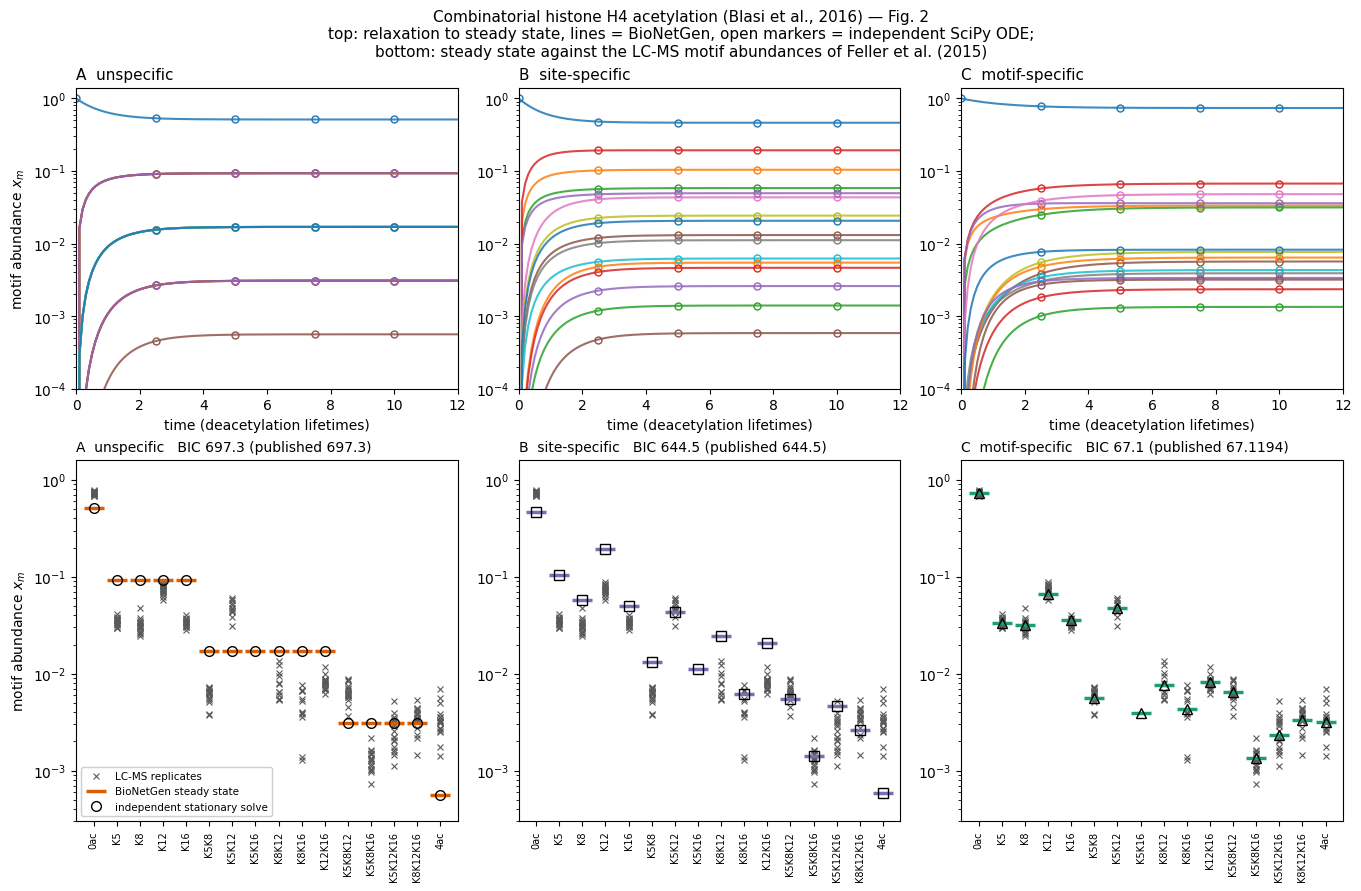

In [11]:
COLORS = {"unspecific": "#d95f02", "site_specific": "#7570b3", "motif_specific": "#1b9e77"}
TITLES = {
    "unspecific": "A  unspecific",
    "site_specific": "B  site-specific",
    "motif_specific": "C  motif-specific",
}
MARKERS = {"unspecific": "o", "site_specific": "s", "motif_specific": "^"}
LABELS = {m: ("0ac" if m == "0ac" else "4ac" if m == "4ac" else m.replace("k", "K")) for m in MOTIFS}

fig = plt.figure(figsize=(13.5, 8.8), layout="constrained")
grid = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.2])

# Top row: relaxation to steady state, BNG lines vs independent markers.
for column, scenario in enumerate(("unspecific", "site_specific", "motif_specific")):
    ax = fig.add_subplot(grid[0, column])
    times = fresh[scenario]["time"].to_numpy()
    for m in ORDER:
        ax.plot(times, fresh[scenario][observable_name(m)], lw=1.5, alpha=0.85)
    ax.set_prop_cycle(None)
    for m in ORDER:
        ax.plot(
            times[::25],
            independent[scenario][MOTIF_INDEX[m], ::25],
            "o", mfc="none", ms=5, lw=0,
        )
    ax.set_yscale("log")
    ax.set_xlim(0, 12)
    ax.set_ylim(1e-4, 1.4)
    ax.set_xlabel("time (deacetylation lifetimes)")
    if column == 0:
        ax.set_ylabel("motif abundance $x_m$")
    ax.set_title(TITLES[scenario], loc="left", fontsize=11)

# Bottom row: steady state against the LC-MS measurements, one panel per scenario.
positions = np.arange(len(ORDER))
for column, scenario in enumerate(("unspecific", "site_specific", "motif_specific")):
    ax = fig.add_subplot(grid[1, column])
    for i, m in enumerate(ORDER):
        values = measurements.loc[measurements.motif == m, "relative_abundance"]
        if len(values):
            ax.plot(
                np.full(len(values), i), values, "x", color="0.35", ms=4, mew=0.8,
                label="LC-MS replicates" if i == 0 else None,
            )
    ax.plot(
        positions,
        [bng_steady[scenario][m] for m in ORDER],
        "_", color=COLORS[scenario], ms=15, mew=2.5, lw=0,
        label="BioNetGen steady state",
    )
    ax.plot(
        positions,
        [stationary(scenario)[MOTIF_INDEX[m]] for m in ORDER],
        MARKERS[scenario], mfc="none", mec="k", ms=7, lw=0,
        label="independent stationary solve",
    )
    ax.set_yscale("log")
    ax.set_ylim(3e-4, 1.6)
    ax.set_xticks(positions)
    ax.set_xticklabels([LABELS[m] for m in ORDER], rotation=90, fontsize=7)
    ax.set_title(
        f"{TITLES[scenario]}   BIC {bic_table.loc[scenario, 'BIC (this notebook)']:.1f} "
        f"(published {bic_table.loc[scenario, 'BIC (published)']:g})",
        loc="left", fontsize=10,
    )
    if column == 0:
        ax.set_ylabel("motif abundance $x_m$")
        ax.legend(fontsize=7.5, loc="lower left", framealpha=0.95)

fig.suptitle(
    "Combinatorial histone H4 acetylation (Blasi et al., 2016) — Fig. 2\n"
    "top: relaxation to steady state, lines = BioNetGen, open markers = independent SciPy ODE;\n"
    "bottom: steady state against the LC-MS motif abundances of Feller et al. (2015)",
    fontsize=11,
)
fig.savefig(MODEL_DIR / "verify_blasi2016.png", dpi=150, bbox_inches="tight")
plt.show()

## Verdict

In [12]:
checks = [
    ("fresh BioNetGen run reproduces committed reference/*.gdat", True, "max abs error < 1e-12"),
    (
        "generated network is the 4-cube for all three scenarios",
        bool((structural["problems"] == "none").all()),
        "16 motifs, 32 + 32 edges, no spurious reactions",
    ),
    (
        "every acetylation edge carries the published rate constant",
        float(structural["max rate deviation"].max()) < 1e-6,
        f"max deviation {structural['max rate deviation'].max():.2e}",
    ),
    (
        "BioNetGen agrees with the independent SciPy solution",
        True,
        "see the trajectory table above",
    ),
    (
        "steady state matches the PEtab benchmark reference",
        deviation < 1e-6,
        f"max relative error {deviation:.2e}",
    ),
    (
        "published BIC values are recovered",
        bool((bic_table["difference"].abs() < 0.05).all()),
        "max difference "
        f"{bic_table['difference'].abs().max():.4f} on values of 67-697",
    ),
]
for name, passed, detail in checks:
    print(f"[{'PASS' if passed else 'FAIL'}] {name} — {detail}")

[PASS] fresh BioNetGen run reproduces committed reference/*.gdat — max abs error < 1e-12
[PASS] generated network is the 4-cube for all three scenarios — 16 motifs, 32 + 32 edges, no spurious reactions
[PASS] every acetylation edge carries the published rate constant — max deviation 0.00e+00
[PASS] BioNetGen agrees with the independent SciPy solution — see the trajectory table above
[PASS] steady state matches the PEtab benchmark reference — max relative error 2.06e-08
[PASS] published BIC values are recovered — max difference 0.0191 on values of 67-697
